# Data Processing Tutorial for FieldLine OPM System
## Here, we will explore the various steps for processing OPM data. 
##### Made by Xan McPherson, 2026

The example data here is from a single 1000Hz tone repeated 200 times over the course of the data collection
Functions require MNE-Python, and I have referenced relevant tutorials from thwir website when applicable for further information. You can find their abundance of knowledge, tutorials, and functions here: https://mne.tools/stable/index.html

### Step 1: Load in and inspect the Raw data, set up Events
Provide the directory to the example data for S005. The raw data comes from the FieldLine system as a ".fif" file. This file contains a lot of metatdata which we will explore, but it does not contain an important matrix that transforms the device space into the MRI space called "dev_head_t". This is not important for evoked time course investigations, but is necessary for source localization and inverse solutions. Here, the file "...raw_trans.fif" contains this matrix which has been calculated using the YORC Coreg GUI. For more information about the creation of this file and MRI segmentations, see Steps 1-3 here: https://github.com/gwilliams-lab/MEG_Pipeline

In [5]:
import mne
#mne.viz.set_3d_backend("notebook") 
import matplotlib.pyplot as plt
import numpy as np
import os

subject = 'S005'
sample_dir = '/Users/alexandria/Documents/STANFORD/code/OPM_processing_tutorial/DATA/'
file = f'sub-{subject}_task-Tone_raw.fif'
trans_file = f'sub-{subject}_task-Tone_raw_trans.fif'

In [6]:
## set your subject dir so MNE and FreeSurfer know where to look for anatomy info
subjects_dir = '/Users/alexandria/Downloads/freesurfer/subjects/'
# os.environ["SUBJECTS_DIR"] = subjects_dir

Lets load in the raw data and take a look at the "info" structure

In [7]:
raw = mne.io.read_raw_fif(os.path.join(sample_dir,file),'default', preload=True)
raw.info

Opening raw data file /Users/alexandria/Documents/STANFORD/code/OPM_processing_tutorial/DATA/sub-S005_task-Tone_raw.fif...
    Range : 0 ... 529299 =      0.000 ...   529.299 secs
Ready.
Reading 0 ... 529299  =      0.000 ...   529.299 secs...


<Info | 19 non-empty values
 bads: 2 items (L301_bz-s69, L504_bz-s86)
 ch_names: L101_bz-s139, L102_bz-s129, L103_bz-s131, L104_bz-s140, ...
 chs: 144 Magnetometers, 1 Stimulus
 custom_ref_applied: False
 description: {"chassis":{"version":"hedscan-0.11.29- ...
 dev_head_t: MEG device -> head transform
 dig: 147 items (3 Cardinal, 144 Extra)
 experimenter: MK
 file_id: 4 items (dict)
 gantry_angle: 0.0
 highpass: 0.0 Hz
 line_freq: 0.0
 lowpass: 500.0 Hz
 meas_date: 2026-03-04 20:29:30 UTC
 meas_id: 4 items (dict)
 nchan: 145
 proj_id: 0
 proj_name: NoTask
 projs: []
 sfreq: 1000.0 Hz
 xplotter_layout: None
>

As you can see, there's lots of stuff in "info"! Most notably, we can see that 2/142 OPM sensors were marked as "bad" on the FieldLine aquisition system during data collection. We can also see only one type of stimulus was detected, which makes sense since we only have one tone playing here. Lets take a look at the raw data in a pop-up window. You can scroll through and see grayed-out channels corresponding to the "bad" ones, and how the data looks without any preprocessing. The bottom-most channel corresponds to the triggers where you can see box waves each time a trigger din is turned on and off. 

In [8]:
raw.plot()

Using qt as 2D backend.


<mne_qt_browser._pg_figure.MNEQtBrowser(0x600003e503c0) at 0x177d13300>

Sometimes, if your stimulus set is too long, or for other reasons, you can combine two raw "fif" files into one raw data structure like this

In [9]:
# files = ['_raw_01.fif','_raw_02.fif']
# raw = mne.io.read_raw_fif(os.path.join(sample_dir,files[0]), preload=True)
# mne.io.concatenate_raws([raw,mne.io.read_raw_fif(os.path.join(sample_dir,files[1]), preload=True)], on_mismatch="ignore")

We can take a deeper look at the events like this, which is useful for more complex paradigms, but lets us see when each trigger was recorded in time, what event ID was read by the aquisition software (called HEDScan), and how many of each trigger were found.

Finding events on: di2
200 events found on stim channel di2
Event IDs: [255]


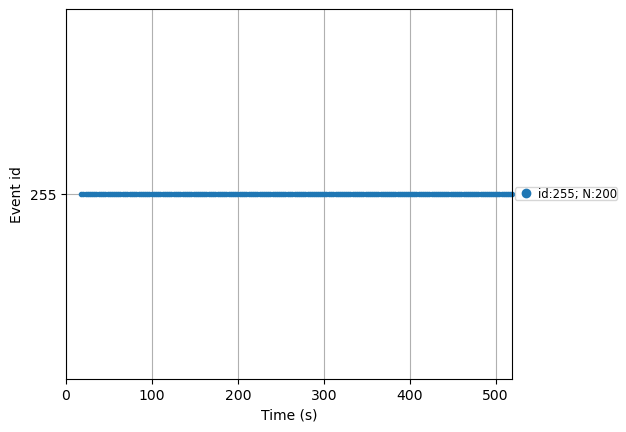

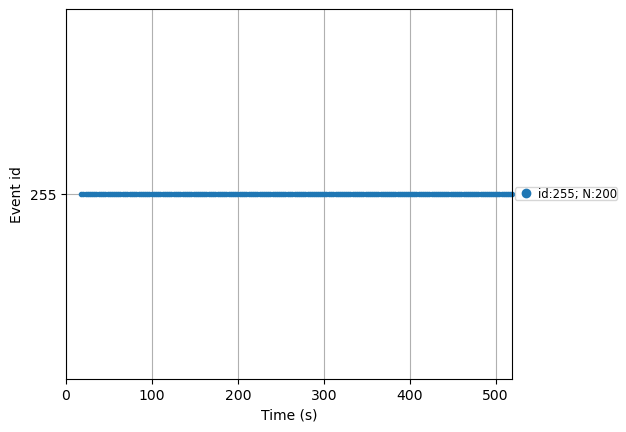

In [10]:
trigger_chan = 'di2' #this is always constant for our OPM system
events = mne.find_events(raw, stim_channel=trigger_chan, shortest_event=1)
mne.viz.plot_events(events, sfreq=raw.info["sfreq"], first_samp=raw.first_samp)

For example, we can use the "events", which are a "n-samples x 3" matrix, to make a Pandas Dataframe. This helps us pass useful information about our stimuli as metadata into further steps. This is a simple example, but shows how you can break your stimuli into different types, such as "tones" or specific frequencies like "1000Hz".

In [11]:
import pandas as pd

code_dict = {255: "tone_1000Hz"}
events_df = pd.DataFrame()
events_df['code'] = events[:, 2] #pull the code from mne.events
events_df['condition'] = [code_dict[c].split('_')[0] for c in events[:, 2]]
events_df['frequency'] = [code_dict[c].split('_')[1] for c in events[:, 2]]
events_df

,code,condition,frequency
0,255,tone,1000Hz
1,255,tone,1000Hz
2,255,tone,1000Hz
3,255,tone,1000Hz
4,255,tone,1000Hz
...,...,...,...
195,255,tone,1000Hz
196,255,tone,1000Hz
197,255,tone,1000Hz
198,255,tone,1000Hz


Now you can imagine if you had different frequencies in your tones, you could have "tone_400Hz" with a different trigger code, or with other stimuli other than tones, you could add them under "condition", etc. 


Lets also take a look at the alignment between the sensor positions and the defaced, morphed person's MRI. This is done using the transformation matrix information in "trans_file". Ideally, we will see that all of the sensors are nicely close to the subject's scalp. This code will create a pop-up window where you can explore the 3D view. One thing to note, you may see three blue, red, green spheres hanging out. Normally, these would correspond to the 3 Fiducial positions used by MNE-Python to coregister the sensors to the MRI. But, since we used the YORC method with the 3D scans of the helmet, the positions of these "fiducials" are meaningless, so do not be alarmed if they appear in spots that look misaligned!

In [12]:
mne.viz.plot_alignment(
            raw.info,
            trans=os.path.join(sample_dir,trans_file),
            subject=subject,
            dig=True,
            meg=["helmet", "sensors"],
            subjects_dir=subjects_dir,
            surfaces="head",
            )

Using pyvistaqt 3d backend.
Using outer_skin.surf for head surface.
Getting helmet for system unknown (derived from 144 MEG channel locations)
Channel types::	mag: 142


### Step 2: Preprocess the Raw Data
Now that we are all set up, we can preprocess the data! The goal here is to remove any magnetic fields, or "noise", that are not coming from neuronal activity in the brain. First step is to filter the data, advocating for a high-pass set around 0.5 Hz to avoid cutting out any brain activity. Lets look at the frequency spectrum of the data before and after doing this. 

Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


/Users/alexandria/Applications/MNE-Python/1.11.0_0/.mne-python/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


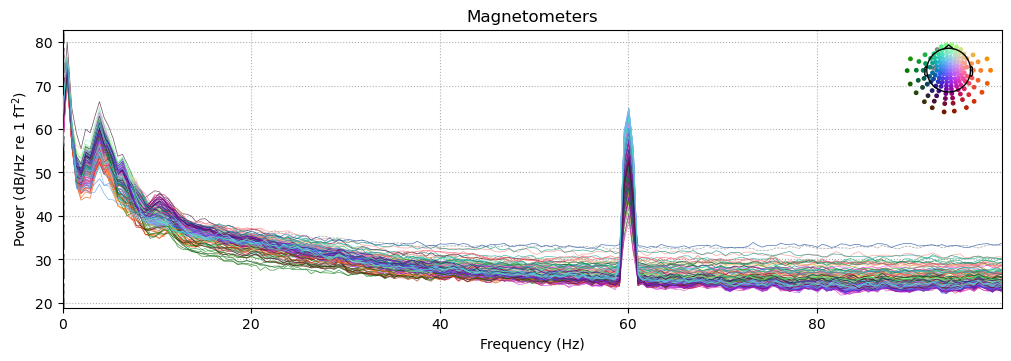

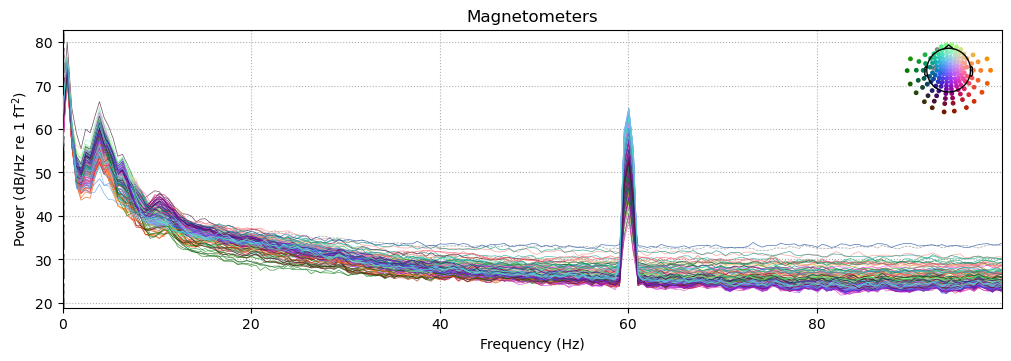

In [13]:
raw.compute_psd(fmax=100).plot(average=False, picks="data", amplitude=False)

We can already see some "bad" channeles that are hovering over all the others with raised noise levels. You can see some are showing up as a dotted line, indicating they have already been marked "bad" in the "info" struture. 

Now, lets filter and take another look

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 80 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 80.00 Hz
- Upper transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 90.00 Hz)
- Filter length: 6601 samples (6.601 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 59 - 61 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 59.35
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 59.10 Hz)
- Upper passband e

/Users/alexandria/Applications/MNE-Python/1.11.0_0/.mne-python/lib/python3.13/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


<mne_qt_browser._pg_figure.MNEQtBrowser(0x600003e08360) at 0x33726ab80>

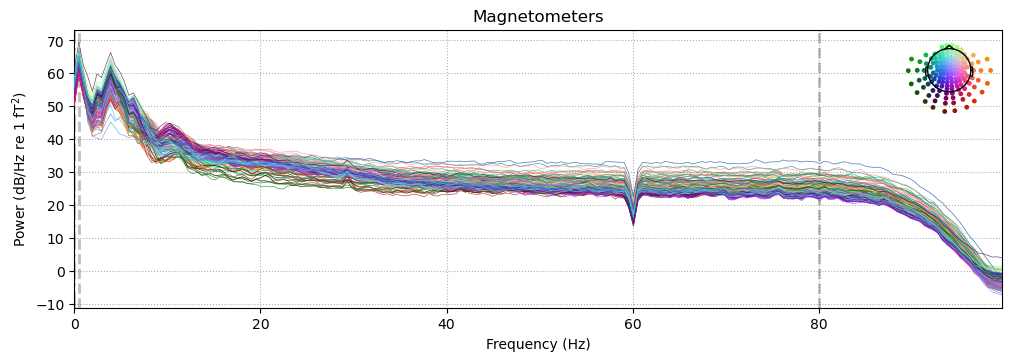

In [14]:
freq_min = 0.5
freq_max = 80
raw.load_data().filter(l_freq=freq_min,h_freq=freq_max)
meg_picks = mne.pick_types(raw.info, meg=True)
raw.notch_filter(freqs=60, picks=meg_picks)
raw.compute_psd(fmax=100).plot(average=False, picks="data", exclude="bads",amplitude=False)
raw.plot()

Seems like 'L107_bz-s143', plotted in blue, has raised noise levels, so we'll just remove that channel too. 

In [15]:
raw.drop_channels('L107_bz-s143')

<Raw | sub-S005_task-Tone_raw.fif, 144 x 529300 (529.3 s), ~581.7 MiB, data loaded>

If a sensor was "excluded" during data collection, usually because for some reason it didn't turn on, it's position may show up as NaN but it will not be marked as "bad". Lets double check for any cases like this to make sure we mark and drop these sensors.

In [16]:
bads_NaNs=[]
for i in range(0,raw.info["nchan"]):
    ch_pos = raw.info["chs"][i]["loc"][:3]
    if np.isnan(ch_pos).any():
        bads_NaNs.append(raw.info["chs"][i]["ch_name"])
raw.drop_channels(bads_NaNs)

<Raw | sub-S005_task-Tone_raw.fif, 144 x 529300 (529.3 s), ~581.7 MiB, data loaded>

From here, there are lots of different choices we can make, but I will suggest using the Signal Space Separation (SSS) method. It is very low assumption and represents the internal data as a series of spatial components while separating out any fields coming from outside the brain. The biggest first step is to ensure that bad channels are marked as bad and are dropped from the SSS process to avoid spatial "mixing" of the noise with the brain signals. There are many parameter choices for us to pass to the function, but I have kept standard ones or changed ones to fit best with OPMs. For more details and examples on Cryogenic MEG systems, see this tutorial: https://mne.tools/stable/auto_tutorials/preprocessing/60_maxwell_filtering_sss.html

In [17]:
## drop bad channels 
bads = raw.info["bads"]
raw.drop_channels(bads)
assert raw.info["bads"] == [] # double check bads were dropped
raw_sss = mne.preprocessing.maxwell_filter(raw,
                                           origin=(0., 0., 0.),
                                           int_order=8, 
                                           ext_order=3, 
                                           calibration=None, 
                                           coord_frame='meg', 
                                           regularize='in', 
                                           ignore_ref=True, 
                                           bad_condition='error', 
                                           mag_scale=100.0, 
                                           extended_proj=(), 
                                           verbose=None)

Maxwell filtering raw data
    No bad MEG channels
    Processing 0 gradiometers and 141 magnetometers
    Using origin 0.0, 0.0, 0.0 mm in the meg frame (17.2, -2.7, 45.8 mm in the head frame)
    Using loaded raw data
        Using 91/95 harmonic components for    0.000  (76/80 in, 15/15 out)
    Processing   52 data chunks of (at least) 10.0 s with 0.0 s overlap and boxcar windowing
    The final 9.3 s will be lumped into the final window
        Using 91/95 harmonic components for    0.000  (76/80 in, 15/15 out)
[done]


Success! Notice the line "Using 91/95 harmonic components". 95 components are the 80 internal spatial components from setting "int_order=8" plus 15 external components from "out_order=3", then some regularization is happening to improve stability. These are recommended from the SSS paper for Cryo-MEG. When adapting to OPMs, the main issue is to ensure that the number of sensors is larger than the number of harmonic spatial components. For us, 144>95, so we are good! But other OPM systems with less channels usually use Homogenous Field Correction (HFC), which is sort of like doing SSS with "int_order=1". A tutorial for HFC on an Triaxial QuSpin OPM system can be found here: https://mne.tools/stable/auto_tutorials/preprocessing/80_opm_processing.html#denoising-regressing-via-homogeneous-field-correction

for now, let's just use the simple preprocessed data with only filtering and bad channel rejection. If you want to see the effects of SSS, uncomment and run the line below.

In [18]:
#raw = raw_sss

### Step 3: Create Epochs based on Events Timing and Evoked Averages
Now, we use our events to splice up our continuous raw data into sections with brain activity and average over the brain's response to each occurance of the same stimuli. Which, for us here, is 200 Epochs of the same brain response, creating one Evoked average. We'll still use our Pandas dataframe as an example, so this code will work for cases where you have more complex stimuli.

Adding metadata with 3 columns
200 matching events found
Setting baseline interval to [-0.05, 0.0] s
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 200 events and 351 original time points ...
0 bad epochs dropped
No projector specified for this dataset. Please consider the method self.add_proj.


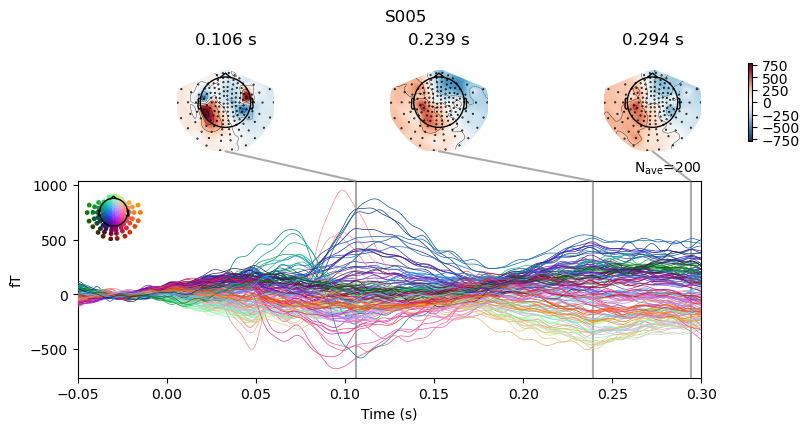

In [19]:
tmin = -0.05  # start of each epoch 
tmax = 0.3  # end of each epoch 
baseline = (None,0) #can also be None for no baseline correction 
# separate out by event ID
epochs = mne.Epochs(raw, 
                    events, 
                    tmin=tmin, 
                    tmax=tmax,
                    baseline=baseline,
                    reject=None,
                    preload=True, 
                    metadata=events_df) #pass our nice data frame as metadata

#specify plotting arguements
ts_args = ts_args = dict(time_unit="s") # can specify limits as ylim=dict(mag=(-400, 400)))
topomap_args = dict(time_unit="s") # you can pass other args here, like 'vmin', 'vmax', 'cmap', etc.

# create an evoked for each "condition" -- which is just each "tone" here -- and plot
evokeds = dict()
query = "condition == '{}'"
for cond in epochs.metadata["condition"].unique():
    evokeds[str(cond)] = epochs[query.format(cond)].average()
    fig = evokeds[cond].plot_joint(times="peaks", ts_args=ts_args, topomap_args=topomap_args,title=subject)

Yay! Here we can check some things. One: theres clealry a peak response, and there's not any major drifts happening as the baseline before 0.00 is very flat. Two: the topography looks like an auditory response with the blue/red dipoles centered around the auditory cortex of both hemispheres. Very good. you can do lots of things from here, like compare accross conditions, and we didn't need any subject MRI data.

### Step 4: Forward and Inverse models, Source Localization

Here, we can take the time/space magnetic fields from each sensor and figure out the most likely dipolar neuronal sources that created these fields in the brain! For this, we need a subject MRI, so we can use S005's. You can download it from the shared C-SHARP drive

This process involved two steps. The Forward Probelm, where we quantify all the possible magnetic fields that could be measured by the sensors from the brain, and the Inverse Problem, where we find the most likely source of the dipoles that created the magnetic field we measured. 

The forward model using the brain's anatomy to determine all possible locations for dipolar activity to be taking place, and how this activity would affect the sensors based on their locations passed in "raw.info". The forward model does not depend on the actual data we collected, and it will help us anatomically and physically constrain the Inverse Problem solution. A good tutorial discussing all this with a 306-channel cryogenic MEG system can be found here https://mne.tools/stable/auto_tutorials/inverse/30_mne_dspm_loreta.html 

Here, the parameters and methods are chosen based on papers by Gwialliams et al, or keeping MNE-Python default suggestions. 

In [20]:
#make forward model
cov = mne.compute_covariance(epochs, tmax=0, projs=None, method="empirical", rank='info')
src = mne.setup_source_space(subject, spacing="ico4", add_dist="patch", subjects_dir=subjects_dir)
conductivity = (0.3, 0.006, 0.3) # for a 3-shell model
model = mne.make_bem_model(subject=subject, ico=4, conductivity=conductivity, subjects_dir=subjects_dir)
bem = mne.make_bem_solution(model)
fwd = mne.make_forward_solution(
    raw_sss.info,
    trans=os.path.join(sample_dir,trans_file),
    src=src,
    bem=bem,
    meg=True,
    eeg=False,
    mindist=5.0,
    n_jobs=None,
    verbose=True)

Reducing data rank from 141 -> 141
Estimating covariance using EMPIRICAL
Done.
Number of samples used : 10200
[done]
Setting up the source space with the following parameters:

SUBJECTS_DIR = /Users/alexandria/Downloads/freesurfer/subjects
Subject      = S005
Surface      = white
Icosahedron subdivision grade 4

>>> 1. Creating the source space...

Doing the icosahedral vertex picking...
Loading /Users/alexandria/Downloads/freesurfer/subjects/S005/surf/lh.white...
Mapping lh S005 -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Users/alexandria/Downloads/freesurfer/subjects/S005/surf/lh.sphere...
Setting up the triangulation for the decimated surface...
loaded lh.white 2562/165747 selected to source space (ico = 4)

Loading /Users/alexandria/Downloads/freesurfer/subjects/S005/surf/rh.white...
Mapping rh S005 -> ico (4) ...
    Triangle neighbors and vertex normals...
Loading geometry from /Users/alexandria/Downloads/freesurfer/subjects/S005/surf/rh.sph

Now, we can do the Inverse Problem using our forward model to help us contrains all of the possible solutions for the neuronal activity that could have caused our measured data. This is a very ill-posed problem because infinitely many different currents can create the same magnetic field, so having the anatomy as a constraint helps a lot. There are also loads of ways to solve the inverse problem that provide further constaints based on noise, ect. We will choose Dynamic Statistical Parameter Mapping (dSPM), which specifically uses the subject anatomy to weight possible locations for dipole activity. 

Each different evoked, corresponding to a different condition, will be its own inverse solution.

In [21]:
query = "condition == '{}"
for cond in epochs.metadata["condition"].unique():
    #make the inverse operator
    inv_operator = mne.minimum_norm.make_inverse_operator(evokeds[cond].info, 
                                                          fwd, #pass the forward model we made
                                                          cov, #information about covariance
                                                          loose = 1, #these three parameters are for non-fixed dipole orientations
                                                          depth = None, 
                                                          fixed = False)
    method = "dSPM"  # could choose MNE, sLORETA, or eLORETA instead
    snr = 2.0
    lambda2 = 1.0 / snr**2
    # now, we apply the inverse operator to each evoked average, and create the source time course (STC)
    stc, residual = mne.minimum_norm.apply_inverse(
        evokeds[cond],
        inv_operator,
        lambda2,
        method=method,
        pick_ori=None,
        return_residual=True,
        verbose=True)
    
    #and visualize
    vertno_max, time_max = stc.get_peak(hemi="rh")
    surfer_kwargs = dict(
        hemi="split",
        subjects_dir=subjects_dir,
        views="lateral",
        initial_time=time_max,
        time_unit="s",
        size=(800, 800),
        smoothing_steps=10)
    brain = stc.plot(**surfer_kwargs)
    brain.add_foci(
        vertno_max,
        coords_as_verts=True,
        hemi="rh",
        color="blue",
        scale_factor=0.6,
        alpha=0.5)
    brain.add_text(0.1, 0.9, str(method)+", "+str(subject), "title", font_size=14)

Computing inverse operator with 141 channels.
    141 out of 141 channels remain after picking
Selected 141 channels
Whitening the forward solution.
Computing rank from covariance with rank=None
    Using tolerance 7.6e-13 (2.2e-16 eps * 141 dim * 24  max singular value)
    Estimated rank (mag): 141
    MAG: rank 141 computed from 141 data channels with 0 projectors
    Setting small MAG eigenvalues to zero (without PCA)
Creating the source covariance matrix
Adjusting source covariance matrix.
Computing SVD of whitened and weighted lead field matrix.
    largest singular value = 2.35956
    scaling factor to adjust the trace = 5.85609e+20 (nchan = 141 nzero = 0)
Preparing the inverse operator for use...
    Scaled noise and source covariance from nave = 1 to nave = 200
    Created the regularized inverter
    The projection vectors do not apply to these channels.
    Created the whitener using a noise covariance matrix with rank 141 (0 small eigenvalues omitted)
    Computing noise-no

Which will produce a nice plot for you to see, and you can mess with the scales and see the activation over time! Yay!!
        